In [7]:
from typing import TypedDict, Literal, Optional, Dict, Any
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


from env_config import config

from langchain.tools import tool
from langchain.chat_models import init_chat_model


llm = init_chat_model(
    "deepseek-chat",
    model_provider="openai",
    api_key=config.deepseek_api_key,
    base_url="https://api.deepseek.com",
    temperature=0
)



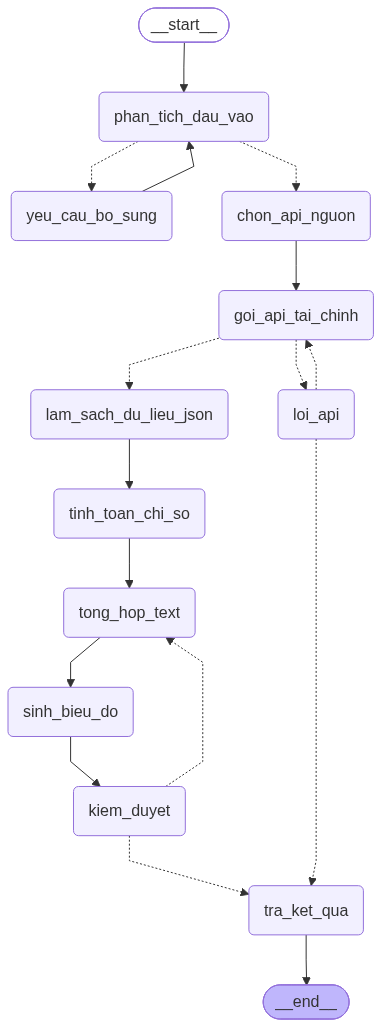

🚀 Đang khởi chạy quy trình phân tích...

-> [Node] Phân Tích Đầu Vào
✅ Đã hoàn thành bước: phan_tich_dau_vao
----------------------------------------
-> [Node] Chọn API Nguồn
✅ Đã hoàn thành bước: chon_api_nguon
----------------------------------------
-> [Node] Gọi API Tài Chính
✅ Đã hoàn thành bước: goi_api_tai_chinh
----------------------------------------
-> [Node] Làm Sạch Dữ Liệu JSON
✅ Đã hoàn thành bước: lam_sach_du_lieu_json
----------------------------------------
-> [Node] Tính Toán Chỉ Số (Pandas)
✅ Đã hoàn thành bước: tinh_toan_chi_so
----------------------------------------
-> [Node] Tổng Hợp Báo Cáo (Text)
✅ Đã hoàn thành bước: tong_hop_text
----------------------------------------
-> [Node] Sinh Biểu Đồ
✅ Đã hoàn thành bước: sinh_bieu_do
----------------------------------------
-> [Node] Kiểm Duyệt Báo Cáo
✅ Đã hoàn thành bước: kiem_duyet
----------------------------------------
-> [Node] Trả Kết Quả Cuối Cùng
✅ Đã hoàn thành bước: tra_ket_qua
--------------------------

In [12]:

# 1. Định nghĩa State của Workflow
# ==========================================
class FinancialWorkflowState(TypedDict):
    """
    Trạng thái (State) chứa tất cả dữ liệu được truyền giữa các bước (nodes) trong LangGraph.
    Bạn có thể điều chỉnh hoặc thêm các trường dữ liệu tùy theo logic thực tế.
    """
    input_text: str
    missing_info: bool  # True nếu thiếu thông tin (Mã CP, Kỳ báo cáo)
    
    # Dữ liệu API
    api_endpoint: Optional[str]
    api_error: bool
    retry_count: int
    
    # Xử lý dữ liệu
    raw_data: Optional[Dict[str, Any]]
    clean_data: Optional[Dict[str, Any]]
    metrics: Optional[Dict[str, Any]]
    
    # Báo cáo
    report_text: str
    chart_data: Optional[Any]
    is_report_approved: bool
    
    final_result: str


# ==========================================
# 2. Định nghĩa các Nodes (Các hàm thực thi)
# ==========================================
def phan_tich_dau_vao(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Nhận yêu cầu và phân tích đầu vào (Mã CP, Kỳ báo cáo...)"""
    print("-> [Node] Phân Tích Đầu Vào")
    # TODO: Thêm logic phân tích LLM ở đây (Xác định thiếu thông tin hay không)
    return state

def yeu_cau_bo_sung(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Yêu cầu người dùng bổ sung thông tin"""
    print("-> [Node] Yêu Cầu Bổ Sung Thông Tin")
    # TODO: Logic hỏi người dùng và cập nhật state
    return state

def chon_api_nguon(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Lập kế hoạch: Chọn API nguồn để gọi"""
    print("-> [Node] Chọn API Nguồn")
    # TODO: Xác định endpoint dựa vào state.input_text
    return state

def goi_api_tai_chinh(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Gọi API tài chính lấy dữ liệu"""
    print("-> [Node] Gọi API Tài Chính")
    # TODO: Logic gọi API thực tế
    return state

def loi_api(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Xử lý khi API lỗi mạng / hết quota / không có dữ liệu"""
    print("-> [Node] Xử lý Lỗi API")
    # TODO: Logic tăng retry_count, hoặc chọn API dự phòng
    return state

def lam_sach_du_lieu_json(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Làm sạch dữ liệu JSON trả về từ API"""
    print("-> [Node] Làm Sạch Dữ Liệu JSON")
    # TODO: Loại bỏ dữ liệu null, chuẩn hóa format
    return state

def tinh_toan_chi_so(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Tính toán chỉ số (sử dụng Pandas Tool)"""
    print("-> [Node] Tính Toán Chỉ Số (Pandas)")
    # TODO: Tính toán các chỉ số tài chính từ clean_data
    return state

def tong_hop_text(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Tổng hợp nội dung báo cáo bằng text"""
    print("-> [Node] Tổng Hợp Báo Cáo (Text)")
    # TODO: Sử dụng LLM để viết báo cáo từ metrics
    return state

def sinh_bieu_do(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Sinh biểu đồ đính kèm báo cáo"""
    print("-> [Node] Sinh Biểu Đồ")
    # TODO: Tạo file ảnh biểu đồ / dữ liệu biểu đồ
    return state

def kiem_duyet(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Kiểm duyệt báo cáo (thiếu ý, sai format...)"""
    print("-> [Node] Kiểm Duyệt Báo Cáo")
    # TODO: Đánh giá chất lượng báo cáo, cập nhật is_report_approved
    return state

def tra_ket_qua(state: FinancialWorkflowState) -> FinancialWorkflowState:
    """Trả kết quả cuối cùng (hoặc báo lỗi) cho người dùng"""
    print("-> [Node] Trả Kết Quả Cuối Cùng")
    # TODO: Gộp text và biểu đồ lại trả cho người dùng
    return state


# ==========================================
# 3. Định nghĩa các Hàm Rẽ Nhánh (Conditional Edges)
# ==========================================
def check_input_status(state: FinancialWorkflowState) -> Literal["chon_api_nguon", "yeu_cau_bo_sung"]:
    """Kiểm tra xem đầu vào đã đủ chưa"""
    if state.get("missing_info"):
        return "yeu_cau_bo_sung"
    return "chon_api_nguon"

def check_api_status(state: FinancialWorkflowState) -> Literal["lam_sach_du_lieu_json", "loi_api"]:
    """Kiểm tra kết quả gọi API"""
    if state.get("api_error"):
        return "loi_api"
    return "lam_sach_du_lieu_json"

def check_api_retry(state: FinancialWorkflowState) -> Literal["goi_api_tai_chinh", "tra_ket_qua"]:
    """Kiểm tra số lần thử lại API (Fallback - Tối đa 3 lần)"""
    if state.get("retry_count", 0) < 3:
        return "goi_api_tai_chinh"
    return "tra_ket_qua"

def check_report_quality(state: FinancialWorkflowState) -> Literal["tong_hop_text", "tra_ket_qua"]:
    """Kiểm tra xem báo cáo có đạt chất lượng không"""
    if not state.get("is_report_approved"):
        return "tong_hop_text"
    return "tra_ket_qua"


# ==========================================
# 4. Xây dựng Đồ Thị (Graph Builder)
# ==========================================
def build_financial_graph():
    workflow = StateGraph(FinancialWorkflowState)

    # Đăng ký các Nodes
    workflow.add_node("phan_tich_dau_vao", phan_tich_dau_vao)
    workflow.add_node("yeu_cau_bo_sung", yeu_cau_bo_sung)
    workflow.add_node("chon_api_nguon", chon_api_nguon)
    workflow.add_node("goi_api_tai_chinh", goi_api_tai_chinh)
    workflow.add_node("loi_api", loi_api)
    workflow.add_node("lam_sach_du_lieu_json", lam_sach_du_lieu_json)
    workflow.add_node("tinh_toan_chi_so", tinh_toan_chi_so)
    workflow.add_node("tong_hop_text", tong_hop_text)
    workflow.add_node("sinh_bieu_do", sinh_bieu_do)
    workflow.add_node("kiem_duyet", kiem_duyet)
    workflow.add_node("tra_ket_qua", tra_ket_qua)

    # ------------------------------------------
    # Thiết lập các Edges (Luồng đi)
    # ------------------------------------------
    
    # Bước Nhận Yêu Cầu
    workflow.add_edge(START, "phan_tich_dau_vao")
    
    # Phân Tích Đầu Vào -> [Chọn API | Yêu Cầu Bổ Sung]
    workflow.add_conditional_edges("phan_tich_dau_vao", check_input_status)
    workflow.add_edge("yeu_cau_bo_sung", "phan_tich_dau_vao")

    # Lập Kế Hoạch
    workflow.add_edge("chon_api_nguon", "goi_api_tai_chinh")

    # Gọi API Tài Chính -> [Xử Lý Dữ Liệu | Lỗi API]
    workflow.add_conditional_edges("goi_api_tai_chinh", check_api_status)
    
    # Lỗi API -> [Thử lại (Gọi API) | Trả Kết Quả (Sau 3 lần)]
    workflow.add_conditional_edges("loi_api", check_api_retry)

    # Xử Lý Dữ Liệu
    workflow.add_edge("lam_sach_du_lieu_json", "tinh_toan_chi_so")
    workflow.add_edge("tinh_toan_chi_so", "tong_hop_text")

    # Viết Báo Cáo
    workflow.add_edge("tong_hop_text", "sinh_bieu_do")
    workflow.add_edge("sinh_bieu_do", "kiem_duyet")

    # Kiểm Duyệt -> [Viết Lại | Trả Kết Quả]
    workflow.add_conditional_edges("kiem_duyet", check_report_quality)

    # Trả Kết Quả -> Kết thúc
    workflow.add_edge("tra_ket_qua", END)

    # Compile đồ thị
    return workflow.compile()


# Instance của Graph để chạy
app = build_financial_graph()
display(Image(app.get_graph().draw_mermaid_png()))

if __name__ == "__main__":
    # Ví dụ khởi chạy đồ thị
    initial_state = {
        "input_text": "Phân tích tài chính công ty FPT năm 2023",
        "missing_info": False,
        "api_error": False,
        "retry_count": 0,
        "is_report_approved": True
    }
    
    print("🚀 Đang khởi chạy quy trình phân tích...\n")
    # Stream kết quả từng bước một
    for output in app.stream(initial_state):
        # In ra node vừa chạy xong để theo dõi
        for node_name, state_update in output.items():
            print(f"✅ Đã hoàn thành bước: {node_name}")
            print("-" * 40)
